In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive"

'2023BCS0214,K.Sri Lalitha,DBMS LAB-1.pdf'
'2023BCS0223,CH.MOUNIKA, COMPUTER NETWORS ASSIGNMENT.pdf'
'2023BCS0223,Ch.Mounika,DBMS lab-1.pdf'
'2023BCS0223,CH.MOUNIKA, ENGLISH ASSIGNMENT .pdf'
'2023BCS0223,CH MOUNIKA MATHS ASSIGNMENT.pdf'
'2023BCS0223,CH MOUNIKA,MATHS ASSIGNMENT.pdf'
'2023bcs0223,ch.mounika,ooad tutorial.pdf'
'2023bcs0223,ch mounika.pdf'
'2023BCS0223,MATHS ASSIGNMENT.pdf'
'2023BCS0223,TOC assignment-2 (1).pdf'
'2023BCS0223,TOC assignment-2.pdf'
 AI_intern.pdf
 AI_ROLE.pdf
 APPLIED_GENERATIVE_AI.pdf
 asl_alphabet_train
'Ch.Mounika_InternshalaResume (10).pdf'
'CH.MOUNIKA ROLLNO2023BCS0223.pdf'
'Circular-holiday-Assembly Election-2026.pdf'
'Colab Notebooks'
 Dataset
 DEEP_LEARNING.pdf
 DOC-20230918-WA0010..pdf
'exercises-cpp (1) (1).pdf'
'exercises-cpp (1) (2).pdf'
'exercises-cpp (1) (3).pdf'
'exercises-cpp (1) (4).pdf'
'exercises-cpp (1) (5).pdf'
'exercises-cpp (1) (6).pdf'
'exercises-cpp (1) (7).pdf'
'exercises-cpp (1) (8).pdf'
'exercises-cpp (1) (9).pdf'
'exercises-cpp (

In [3]:
import os

print(os.path.exists("/content/drive/MyDrive/GCP_Assignment_Datasets"))
print(os.listdir("/content/drive/MyDrive/GCP_Assignment_Datasets"))

True
['train_dataset', 'test_dataset']


In [4]:
DATASET_ROOT = "/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset"

In [6]:
import os

json_path = os.path.join(DATASET_ROOT, "gcp_marks.json")

print(os.path.exists(json_path))

True


In [7]:
import json

with open(json_path, "r") as f:
    data = json.load(f)

print("Total Images:", len(data))

Total Images: 1000


In [9]:
from collections import Counter

shape_counts = Counter()
missing = 0

for v in data.values():
    if "verified_shape" in v:
        shape_counts[v["verified_shape"]] += 1
    else:
        missing += 1

print("Shape Counts:", shape_counts)
print("Missing Shapes:", missing)

Shape Counts: Counter({'L-Shape': 491, 'Square': 328, 'Cross': 177})
Missing Shapes: 4


In [8]:
import cv2
import os

first_img = list(data.keys())[0]

img_path = os.path.join(DATASET_ROOT, first_img)

print("Path:", img_path)
print("Exists:", os.path.exists(img_path))

img = cv2.imread(img_path)

print("Loaded:", img is not None)

if img is not None:
    print("Shape:", img.shape)

Path: /content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG
Exists: True
Loaded: True
Shape: (3068, 4096, 3)


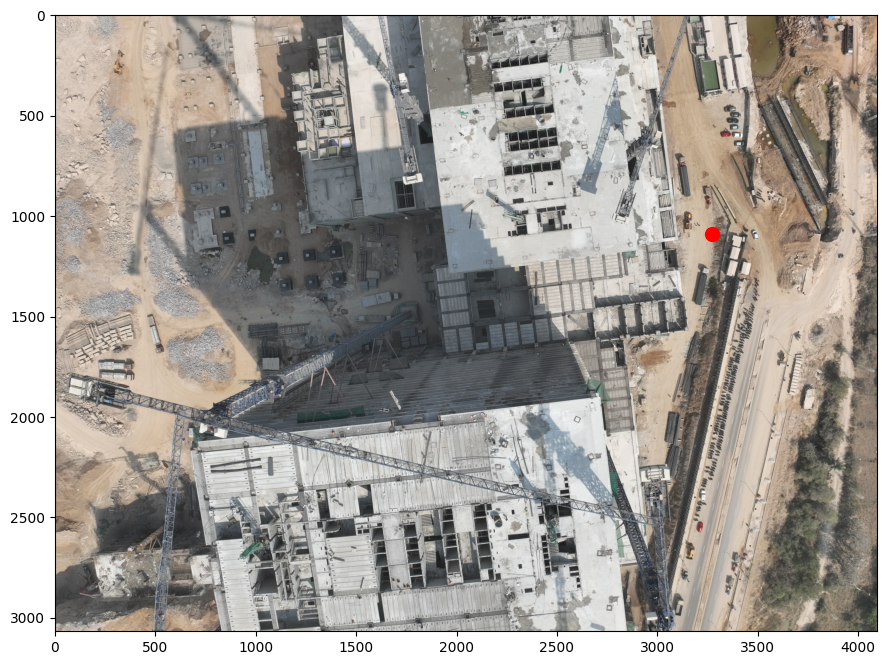

In [10]:
import matplotlib.pyplot as plt
import cv2
import os

path = list(data.keys())[0]

img_path = os.path.join(DATASET_ROOT, path)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x = int(data[path]["mark"]["x"])
y = int(data[path]["mark"]["y"])

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.scatter(x, y, c='red', s=100)
plt.show()

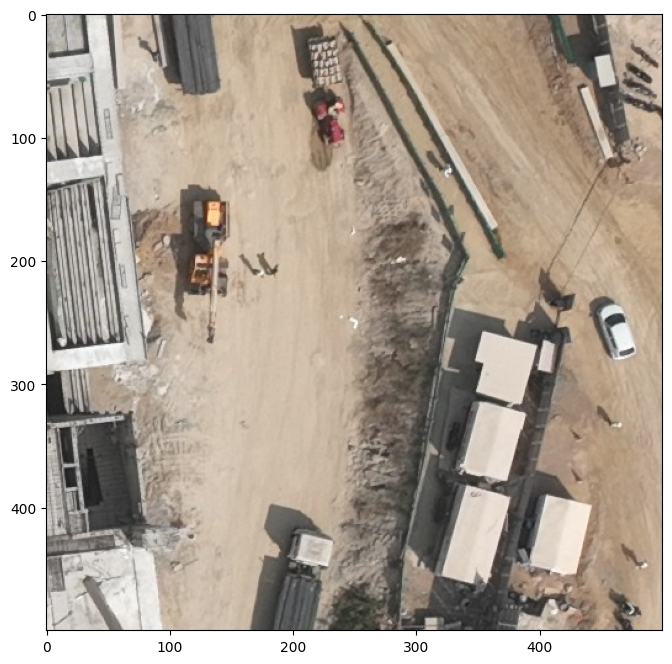

In [11]:
crop_size = 250

crop = img[
    max(0,y-crop_size):y+crop_size,
    max(0,x-crop_size):x+crop_size
]

plt.figure(figsize=(8,8))
plt.imshow(crop)
plt.show()

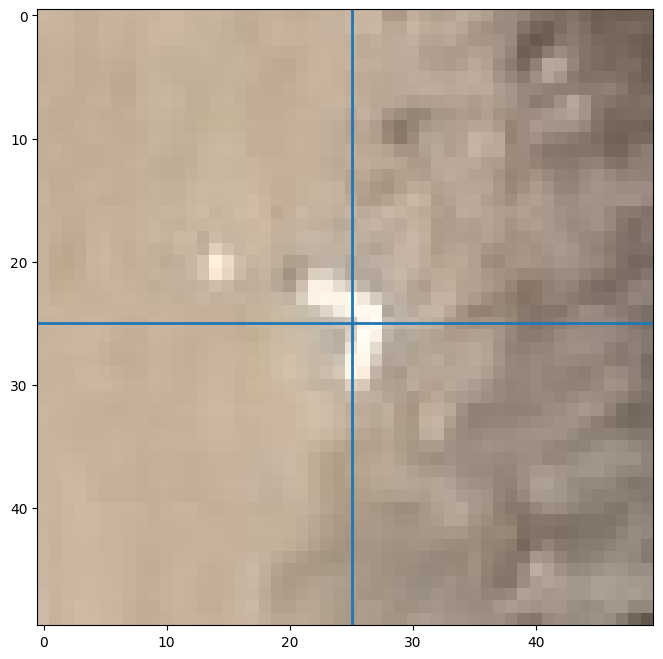

In [18]:
import matplotlib.pyplot as plt
import cv2
import os

path = list(data.keys())[0]

img_path = os.path.join(DATASET_ROOT, path)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x = int(data[path]["mark"]["x"])
y = int(data[path]["mark"]["y"])

crop_size = 25

crop = img[
    max(0, y-crop_size):y+crop_size,
    max(0, x-crop_size):x+crop_size
]

cx = crop.shape[1] // 2
cy = crop.shape[0] // 2

plt.figure(figsize=(8,8))
plt.imshow(crop)

plt.axhline(cy, linewidth=2)
plt.axvline(cx, linewidth=2)

plt.show()

In [15]:
import cv2
import os

sizes = []

for i, path in enumerate(data.keys()):
    img_path = os.path.join(DATASET_ROOT, path)

    img = cv2.imread(img_path)

    if img is not None:
        sizes.append(img.shape[:2])

    if i == 50:
        break

print(set(sizes))

{(3068, 4096), (2730, 4096)}


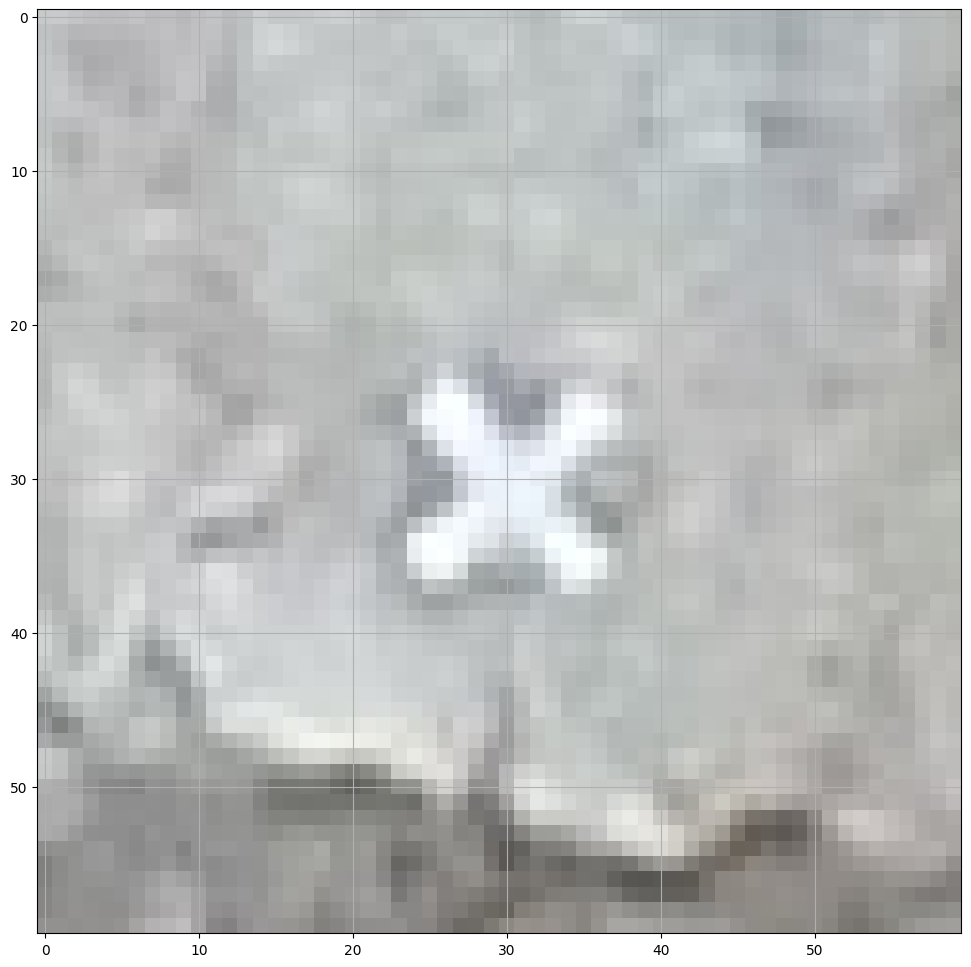

In [26]:
import matplotlib.pyplot as plt
import cv2
import os

path = list(data.keys())[2]

img_path = os.path.join(DATASET_ROOT, path)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x = int(data[path]["mark"]["x"])
y = int(data[path]["mark"]["y"])

crop_size = 30

crop = img[
    max(0,y-crop_size):y+crop_size,
    max(0,x-crop_size):x+crop_size
]

plt.figure(figsize=(12,12))
plt.imshow(crop)
plt.grid()
plt.show()

In [27]:
!pip install ultralytics scikit-learn tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00


In [28]:
import os
import json
import shutil
from pathlib import Path

from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [29]:
DATASET_ROOT = "/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset"
JSON_PATH = os.path.join(
    DATASET_ROOT,
    "gcp_marks.json"
)
OUTPUT_DIR = "/content/gcp_yolo_dataset"

In [30]:
with open(JSON_PATH, "r") as f:
    data = json.load(f)

print("Total Entries:", len(data))

Total Entries: 1000


In [31]:
CLASS_MAP = {
    "Cross": 0,
    "Square": 1,
    "L-Shape": 2
}

In [32]:
samples = []

for img_rel_path, ann in data.items():

    if "verified_shape" not in ann:
        continue

    shape = ann["verified_shape"]

    if shape not in CLASS_MAP:
        continue

    samples.append(
        (
            img_rel_path,
            ann["mark"]["x"],
            ann["mark"]["y"],
            shape
        )
    )

print("Valid Samples:", len(samples))

Valid Samples: 996


In [33]:
labels = [s[3] for s in samples]

train_samples, val_samples = train_test_split(
    samples,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(len(train_samples))
print(len(val_samples))

796
200


In [34]:
for split in ["train", "val"]:

    os.makedirs(
        f"{OUTPUT_DIR}/images/{split}",
        exist_ok=True
    )

    os.makedirs(
        f"{OUTPUT_DIR}/labels/{split}",
        exist_ok=True
    )

In [35]:
BOX_HALF_SIZE=25

In [36]:
def create_label(img_width,img_height,x,y,class_id):

    x_center = x / img_width
    y_center = y / img_height

    width = (2 * BOX_HALF_SIZE) / img_width
    height = (2 * BOX_HALF_SIZE) / img_height

    return (
        f"{class_id} "
        f"{x_center:.6f} "
        f"{y_center:.6f} "
        f"{width:.6f} "
        f"{height:.6f}"
    )

In [37]:
import cv2
def process_split(samples, split):
    for (rel_path,x,y,shape) in tqdm(samples):
        img_path = os.path.join(DATASET_ROOT,rel_path)
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        class_id = CLASS_MAP[shape]
        label_text = create_label(w,h,x,y,class_id)
        file_id = rel_path.replace("/", "_")
        image_out = (
            f"{OUTPUT_DIR}/images/"
            f"{split}/{file_id}"
        )
        label_out = (
            f"{OUTPUT_DIR}/labels/"
            f"{split}/"
            f"{Path(file_id).stem}.txt"
        )
        shutil.copy2(img_path,image_out)
        with open(label_out, "w") as f:
            f.write(label_text)

In [38]:
process_split(train_samples,"train")
process_split(val_samples,"val")

100%|██████████| 200/200 [04:35<00:00,  1.38s/it]


In [39]:
yaml_content = """
path: /content/gcp_yolo_dataset
train: images/train
val: images/val
names:
  0: Cross
  1: Square
  2: L-Shape
"""
with open(f"{OUTPUT_DIR}/data.yaml","w") as f:
    f.write(yaml_content)

In [40]:
print(len(os.listdir(f"{OUTPUT_DIR}/images/train")))
print(len(os.listdir(f"{OUTPUT_DIR}/labels/train")))

796
796


In [41]:
print("Train Images:",len(os.listdir("/content/gcp_yolo_dataset/images/train")))
print("Train Labels:",len(os.listdir("/content/gcp_yolo_dataset/labels/train")))
print("Val Images:",len(os.listdir("/content/gcp_yolo_dataset/images/val")))
print("Val Labels:",len(os.listdir("/content/gcp_yolo_dataset/labels/val")))

Train Images: 796
Train Labels: 796
Val Images: 200
Val Labels: 200


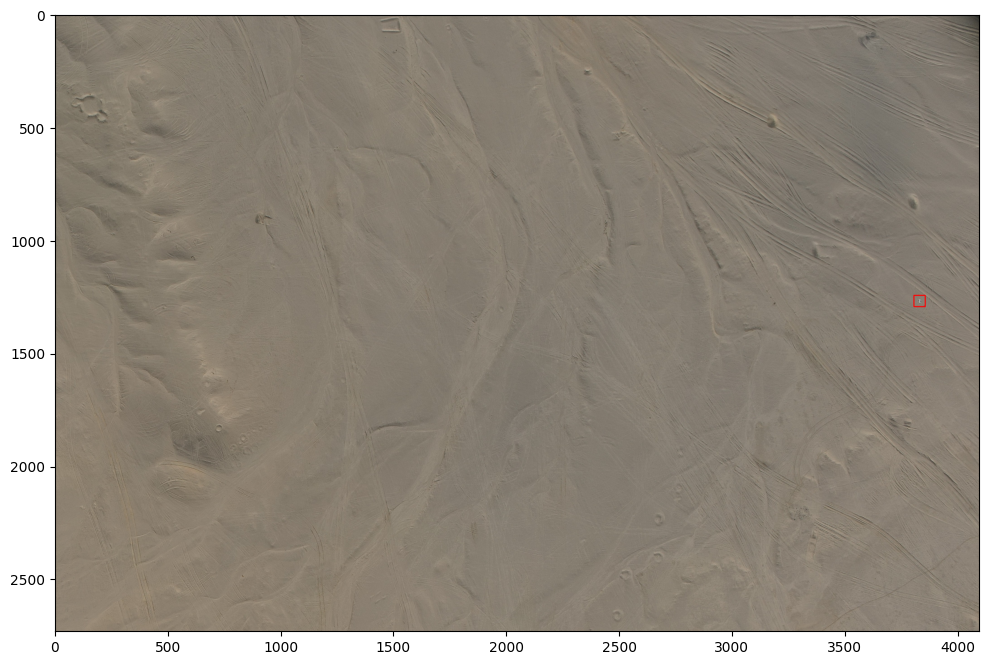

In [47]:
import cv2
import random
import matplotlib.pyplot as plt
import os
img_dir = "/content/gcp_yolo_dataset/images/train"
lbl_dir = "/content/gcp_yolo_dataset/labels/train"
img_file = random.choice(os.listdir(img_dir))
img = cv2.imread(os.path.join(img_dir, img_file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
label_file = os.path.join(lbl_dir,img_file.rsplit(".",1)[0] + ".txt")
with open(label_file) as f:
    line = f.readline().strip().split()
cls, xc, yc, bw, bh = map(float, line)
xc *= w
yc *= h
bw *= w
bh *= h
x1 = int(xc - bw/2)
y1 = int(yc - bh/2)
x2 = int(xc + bw/2)
y2 = int(yc + bh/2)
cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),3)
plt.figure(figsize=(12,8))
plt.imshow(img)
plt.show()

In [48]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [53]:
model = YOLO("yolov8s.pt")

In [54]:
results = model.train(
    data="/content/gcp_yolo_dataset/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    device=0,
    workers=2,
    patience=20,
    project="gcp_detector",
    name="yolov8s_gcp"
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gcp_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_gcp-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [55]:
metrics=model.val()

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2955.7±216.4 MB/s, size: 3713.1 KB)
val: Scanning /content/gcp_yolo_dataset/labels/val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 55.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.1s/it 26.8s
                   all        200        200      0.867       0.89      0.876      0.441
                 Cross         35         35      0.776        0.8      0.738      0.347
                Square         66         66      0.968      0.939      0.949      0.504
               L-Shape         99         99      0.857      0.929      0.941      0.472
Speed: 6.1ms preprocess, 27.3ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val-2

In [56]:
from ultralytics import YOLO

MODEL_PATH = "/content/runs/detect/gcp_detector/yolov8s_gcp-2/weights/best.pt"

model = YOLO(MODEL_PATH)

In [61]:
import random
import os
val_dir = "/content/gcp_yolo_dataset/images/val"
sample_images = random.sample(os.listdir(val_dir), 5)
for img in sample_images:
    results = model.predict(
        source=os.path.join(val_dir, img),
        conf=0.25,
        save=True
    )


image 1/1 /content/gcp_yolo_dataset/images/val/Adani GP-III CG_April_2025_GCP8_DJI_20250502131446_0335_D.JPG: 960x1280 1 Square, 39.0ms
Speed: 9.5ms preprocess, 39.0ms inference, 1.6ms postprocess per image at shape (1, 3, 960, 1280)
Results saved to /content/runs/detect/predict

image 1/1 /content/gcp_yolo_dataset/images/val/scout_966_a7ee1866bbb652c2d0b92546_GCP44_DJI_20260210160017_0800_D.JPG: 960x1280 1 L-Shape, 37.4ms
Speed: 9.2ms preprocess, 37.4ms inference, 2.2ms postprocess per image at shape (1, 3, 960, 1280)
Results saved to /content/runs/detect/predict

image 1/1 /content/gcp_yolo_dataset/images/val/Vedanta GOA Bicholim_MCDR 2024_GCP19_15_3_DJI_0324.JPG: 864x1280 1 L-Shape, 35.8ms
Speed: 7.7ms preprocess, 35.8ms inference, 1.3ms postprocess per image at shape (1, 3, 864, 1280)
Results saved to /content/runs/detect/predict

image 1/1 /content/gcp_yolo_dataset/images/val/Vedanta GOA Bicholim_MCDR 2024_GCP19_15_3_DJI_0378.JPG: 864x1280 1 L-Shape, 35.0ms
Speed: 8.1ms preproces

In [63]:
import os
TEST_ROOT = "/content/drive/MyDrive/GCP_Assignment_Datasets/test_dataset"
test_images = []
for root, dirs, files in os.walk(TEST_ROOT):
    for file in files:
        if file.lower().endswith((".jpg",".jpeg",".png")):
            test_images.append(os.path.join(root,file))
print("Total Test Images:", len(test_images))

Total Test Images: 300


In [64]:
multi_detection = 0
total = 0
for img_path in test_images[:100]:
    results = model.predict(img_path,conf=0.5,verbose=False)
    total += 1
    if len(results[0].boxes) > 1:
        multi_detection += 1
print("Multiple detections:", multi_detection)
print("Checked:", total)

Multiple detections: 7
Checked: 100


In [79]:
import json
import numpy as np
import os
CLASS_MAP = {
    0: "Cross",
    1: "Square",
    2: "L-Shape"
}
predictions = {}
missed_images = []
for img_path in test_images:
    results = model.predict(img_path,conf=0.01,verbose=False)

    relative_path = os.path.relpath(
        img_path,
        TEST_ROOT
    ).replace("\\", "/")

    boxes = results[0].boxes

    if len(boxes) == 0:
        missed_images.append(relative_path)
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        predictions[relative_path] = {
            "mark": {
                "x": float(w / 2),
                "y": float(h / 2)
             },
             "verified_shape": "L-Shape"
        }
        continue

    best_idx = int(boxes.conf.cpu().numpy().argmax())

    box = boxes[best_idx]

    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    center_x = float((x1 + x2) / 2)
    center_y = float((y1 + y2) / 2)

    cls_id = int(box.cls[0])

    predictions[relative_path] = {
        "mark": {
            "x": center_x,
            "y": center_y
        },
        "verified_shape": CLASS_MAP[cls_id]
    }

In [80]:
with open("predictions.json", "w") as f:
    json.dump(predictions,f,indent=4)
print("Predictions:", len(predictions))
print("Missed:", len(missed_images))

Predictions: 300
Missed: 4


In [81]:
first_key = list(predictions.keys())[0]

print(first_key)
print(predictions[first_key])

Amli Limestone Mine/MCDR_2024/GCP-78/DJI_20240414123637_0249_V.JPG
{'mark': {'x': 1558.55126953125, 'y': 1760.856201171875}, 'verified_shape': 'L-Shape'}


In [82]:
print("Total test images:", len(test_images))
print("Predictions:", len(predictions))
print("Missed:", len(missed_images))

Total test images: 300
Predictions: 300
Missed: 4


In [83]:
with open("predictions.json", "w") as f:
    json.dump(predictions, f, indent=4)

In [84]:
import json

with open("predictions.json") as f:
    pred = json.load(f)

print(len(pred))

300


In [85]:
import os

print(os.path.exists("/content/runs/detect/gcp_detector/yolov8s_gcp-2/weights/best.pt"))

True


In [86]:
from google.colab import files
files.download("/content/runs/detect/gcp_detector/yolov8s_gcp-2/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>